In [3]:
# Cargamos librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Tomamos la tabla que contiene las galaxias en el snap 28 (z = 0)

data = pd.read_csv('data/MuestraMZR_RefL0100N1504_snap_28.dat')

In [5]:
data.head()

,GalaxyID,GroupID,SnapNum,SubGroupNumber,Stars_Mass,BlackHoleMass,SF_Mass,SF_Oxygen,SF_Hydrogen
0,8633758,28000000000698,28,1,1.124918e+10,27557768.00,2.736493e+07,0.013666,0.689737
1,8636849,28000000000711,28,1,2.305168e+10,9010794.00,3.109487e+09,0.013036,0.684317
2,8638278,28000000000713,28,1,1.384732e+10,1735177.75,2.419448e+09,0.013081,0.682808
3,8640505,28000000000729,28,1,2.046221e+10,45367132.00,8.192070e+08,0.014420,0.673389
4,8641614,28000000000730,28,1,1.295054e+10,1044806.25,1.387447e+09,0.018942,0.645510


In [6]:
# Longitud de registros
print('Total de registros:', len(data)) # Condiciones sub.SnapNum=28 and sub.BlackHoleMass>0 and sub.Stars_Mass>10000000000.0 and sub.SF_Oxygen>0 and sub.SF_Hydrogen>0 
print('Total de registros siendo centrales:', len(data[data['SubGroupNumber']==0])) # Condiciones sub.SnapNum=28 and sub.SubGroupNumber=0 and sub.BlackHoleMass>0 and sub.Stars_Mass>10000000000.0 and sub.SF_Oxygen>0 and sub.SF_Hydrogen>0    


Total de registros: 3093
Total de registros siendo centrales: 2172


In [7]:
# Nos concentramos en las galaxias centrales (SubGroupNumber=0). POsteriormente se podrían incluir las demás para el estudio del medio ambiente.
data_centrales = data[data['SubGroupNumber']==0]

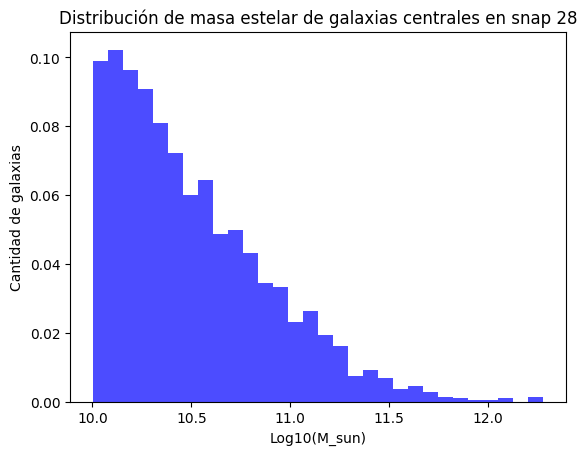

In [8]:
# Reaizamos un histograma de la masa estelar de las galaxias centrales.
plt.hist(np.log10(data_centrales['Stars_Mass']),weights=np.ones_like(data_centrales['Stars_Mass']) / len(data_centrales['Stars_Mass']), bins=30, log=False, density=False, alpha=0.7, color='blue')
plt.xlabel('Log10(M_sun)')
plt.ylabel('Cantidad de galaxias')
plt.title('Distribución de masa estelar de galaxias centrales en snap 28')
plt.show()

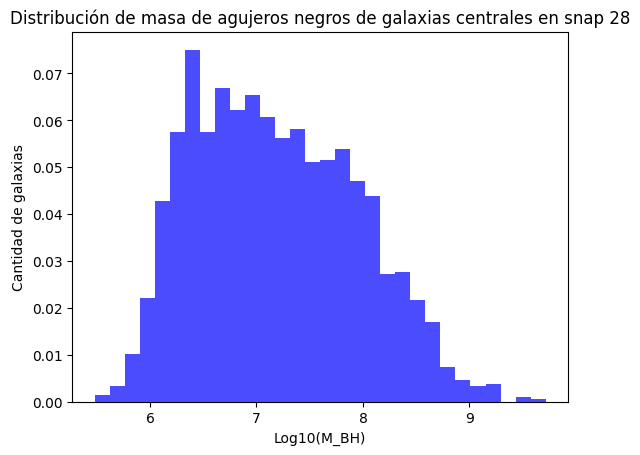

In [9]:
# Reaizamos un histograma de la masa BH de las galaxias centrales.
plt.hist(np.log10(data_centrales['BlackHoleMass']),weights=np.ones_like(data_centrales['BlackHoleMass']) / len(data_centrales['BlackHoleMass']), bins=30, log=False, density=False, alpha=0.7, color='blue')
plt.xlabel('Log10(M_BH)')
plt.ylabel('Cantidad de galaxias')
plt.title('Distribución de masa de agujeros negros de galaxias centrales en snap 28')
plt.show()

In [10]:
# Definimos la abundancia de O como:

data_centrales['metalicidad'] = 12 + np.log10(data_centrales['SF_Oxygen']) - np.log10(data_centrales['SF_Hydrogen']) - np.log10(16)

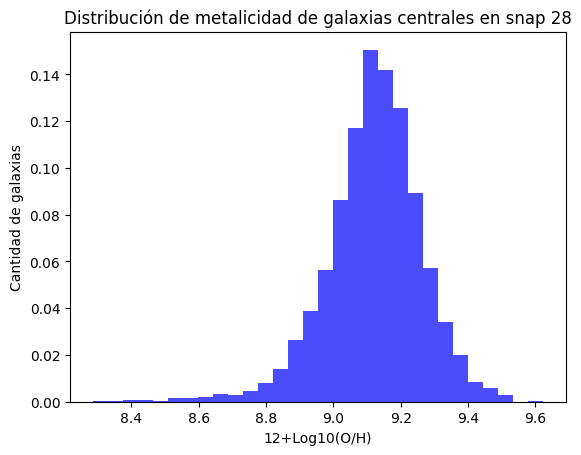

In [11]:
# Realizamos el histogama para la metalicidad
plt.hist(data_centrales['metalicidad'], weights=np.ones_like(data_centrales['metalicidad']) / len(data_centrales['metalicidad']), bins=30, log=False, density=False, alpha=0.7, color='blue')
plt.xlabel('12+Log10(O/H)')
plt.ylabel('Cantidad de galaxias')
plt.title('Distribución de metalicidad de galaxias centrales en snap 28')
plt.show()

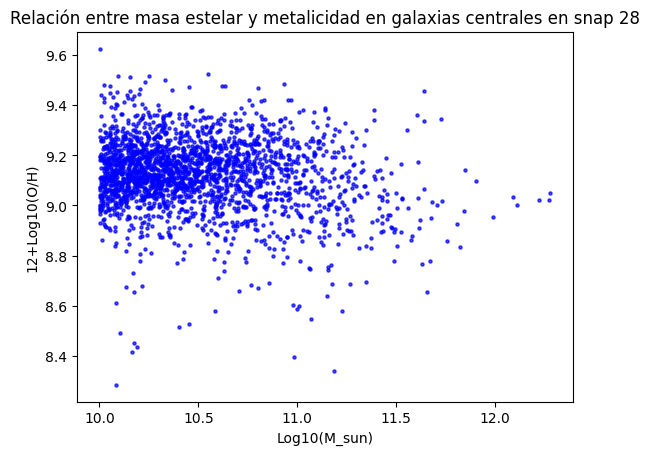

In [ ]:
# Hacemos el scatter plot de la metalicidad en función de la masa estelar

plt.scatter(np.log10(data_centrales['Stars_Mass']), data_centrales['metalicidad'], alpha=0.7, color='blue', s=5)
plt.xlabel('Log10(M_sun)')
plt.ylabel('12+Log10(O/H)')
plt.title('Relación entre masa estelar y metalicidad en galaxias centrales en snap 28')
plt.show()

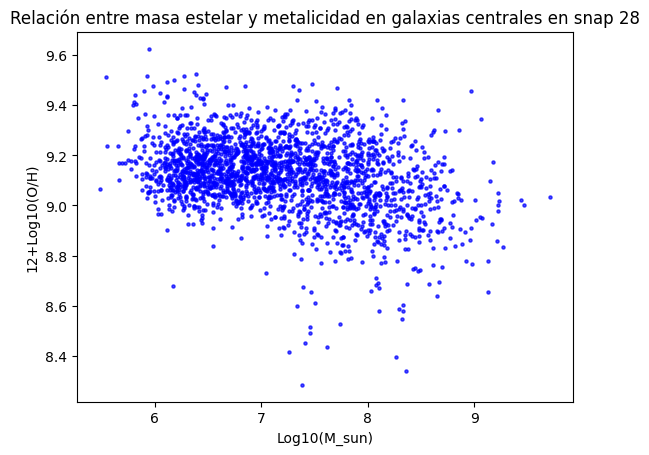

In [ ]:
# Hacemos el scatter plot de la metalicidad en finción de la masa BH

plt.scatter(np.log10(data_centrales['BlackHoleMass']), data_centrales['metalicidad'], alpha=0.7, color='blue', s=5)
plt.xlabel('Log10(M_BH)')
plt.ylabel('12+Log10(O/H)')
plt.title('Relación entre masa estelar y metalicidad en galaxias centrales en snap 28')
plt.show()

In [ ]:
# Guardamos la tabla de galaxias centrales en el plano MZR con M>10^10 M_sun
data_centrales.to_csv('data/data_centrales_snap28.csv', index=False)

In [ ]:
# --------------------------------------------------------------------------------------------